In [ ]:
!pip install -q kaggle
import os
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
print("Kaggle token loaded successfully.")

Kaggle token loaded successfully.


In [ ]:
!kaggle datasets download -d anikannal/solar-power-generation-data -p /content/data --unzip

import pandas as pd

# Load all 4 files
gen_1 = pd.read_csv('/content/data/Plant_1_Generation_Data.csv')
weather_1 = pd.read_csv('/content/data/Plant_1_Weather_Sensor_Data.csv')
gen_2 = pd.read_csv('/content/data/Plant_2_Generation_Data.csv')
weather_2 = pd.read_csv('/content/data/Plant_2_Weather_Sensor_Data.csv')

print("Plant 1 Generation:", gen_1.shape)
print("Plant 1 Weather:", weather_1.shape)
print("Plant 2 Generation:", gen_2.shape)
print("Plant 2 Weather:", weather_2.shape)

Dataset URL: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data
License(s): copyright-authors
100% 1.90M/1.90M [00:01<00:00, 1.64MB/s]

Plant 1 Generation: (68778, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather: (3259, 6)


In [ ]:
# Convert DATE_TIME to datetime for both files
gen_1['DATE_TIME'] = pd.to_datetime(gen_1['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather_1['DATE_TIME'] = pd.to_datetime(weather_1['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Merge on DATE_TIME
df = pd.merge(gen_1, weather_1, on='DATE_TIME', how='inner')

print("Merged shape:", df.shape)
df.head()

Merged shape: (68774, 12)


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68774 non-null  datetime64[ns]
 1   PLANT_ID_x           68774 non-null  int64         
 2   SOURCE_KEY_x         68774 non-null  object        
 3   DC_POWER             68774 non-null  float64       
 4   AC_POWER             68774 non-null  float64       
 5   DAILY_YIELD          68774 non-null  float64       
 6   TOTAL_YIELD          68774 non-null  float64       
 7   PLANT_ID_y           68774 non-null  int64         
 8   SOURCE_KEY_y         68774 non-null  object        
 9   AMBIENT_TEMPERATURE  68774 non-null  float64       
 10  MODULE_TEMPERATURE   68774 non-null  float64       
 11  IRRADIATION          68774 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(2), object(2)
memory usage: 6.3+ MB


In [ ]:
df.isnull().sum()

,0
DATE_TIME,0
PLANT_ID_x,0
SOURCE_KEY_x,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0
PLANT_ID_y,0
SOURCE_KEY_y,0
AMBIENT_TEMPERATURE,0


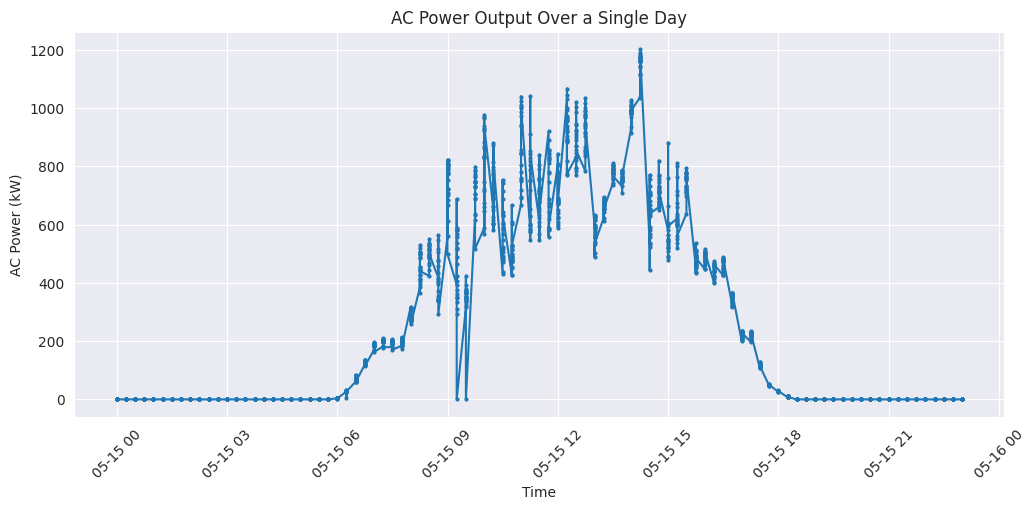

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Daily power generation curve - pick one day to see the sunrise-to-sunset pattern
sample_day = df[df['DATE_TIME'].dt.date == df['DATE_TIME'].dt.date.iloc[100]]

plt.figure(figsize=(12,5))
plt.plot(sample_day['DATE_TIME'], sample_day['AC_POWER'], marker='o', markersize=2)
plt.title('AC Power Output Over a Single Day')
plt.xlabel('Time')
plt.ylabel('AC Power (kW)')
plt.xticks(rotation=45)
plt.show()

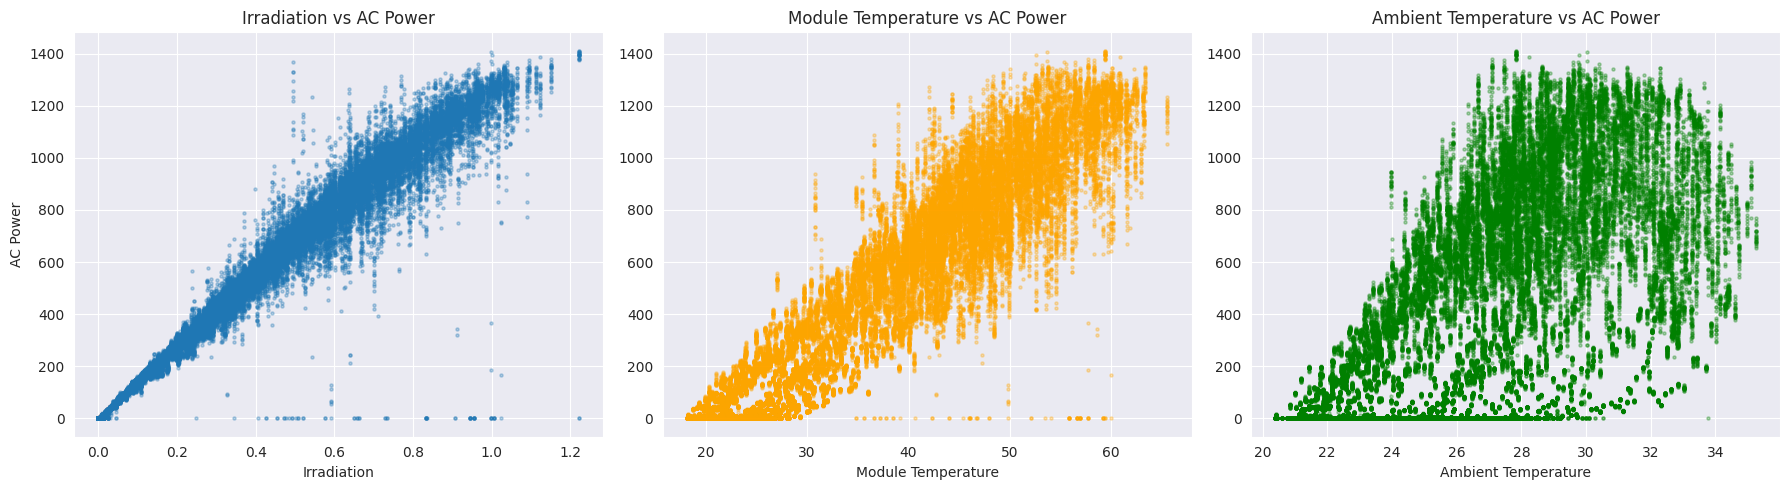

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.3, s=5)
axes[0].set_title('Irradiation vs AC Power')
axes[0].set_xlabel('Irradiation')
axes[0].set_ylabel('AC Power')

axes[1].scatter(df['MODULE_TEMPERATURE'], df['AC_POWER'], alpha=0.3, s=5, color='orange')
axes[1].set_title('Module Temperature vs AC Power')
axes[1].set_xlabel('Module Temperature')

axes[2].scatter(df['AMBIENT_TEMPERATURE'], df['AC_POWER'], alpha=0.3, s=5, color='green')
axes[2].set_title('Ambient Temperature vs AC Power')
axes[2].set_xlabel('Ambient Temperature')

plt.tight_layout()
plt.show()

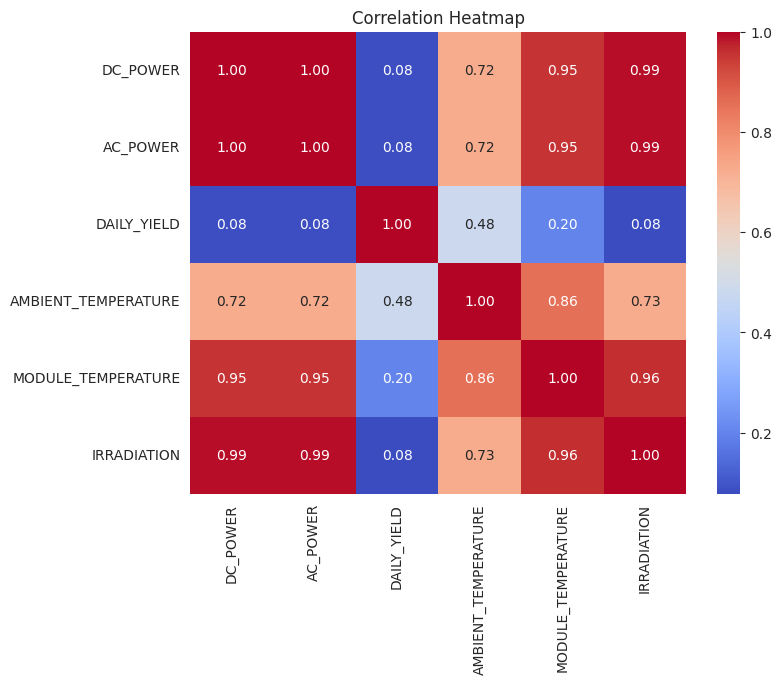

In [ ]:
numeric_cols = df[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Time-based features
df['hour'] = df['DATE_TIME'].dt.hour
df['is_daylight'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)

# Sort by time (critical for lag features)
df = df.sort_values('DATE_TIME').reset_index(drop=True)

# Lag features
df['ac_power_lag_1'] = df['AC_POWER'].shift(1)
df['ac_power_rolling_3'] = df['AC_POWER'].rolling(window=3).mean()

# Drop rows with NaN from lag/rolling only
df = df.dropna(subset=['ac_power_lag_1', 'ac_power_rolling_3']).reset_index(drop=True)

print("Shape after feature engineering:", df.shape)
df.head()

Shape after feature engineering: (68772, 16)


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,is_daylight,ac_power_lag_1,ac_power_rolling_3
0,2020-05-15,4135001,zBIq5rxdHJRwDNY,0.0,0.0,0.0,6339380.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,0,0.0,0.0
1,2020-05-15,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,0.0,7007866.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,0,0.0,0.0
2,2020-05-15,4135001,wCURE6d3bPkepu2,0.0,0.0,0.0,6782598.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,0,0.0,0.0
3,2020-05-15,4135001,uHbuxQJl8lW7ozc,0.0,0.0,0.0,7038681.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,0,0.0,0.0
4,2020-05-15,4135001,rGa61gmuvPhdLxV,0.0,0.0,0.0,7111493.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0,0,0.0,0.0


In [ ]:
# Aggregate across inverters: average power output per timestamp for the whole plant
df_plant = df.groupby('DATE_TIME').agg({
    'DC_POWER': 'mean',
    'AC_POWER': 'mean',
    'DAILY_YIELD': 'mean',
    'AMBIENT_TEMPERATURE': 'mean',
    'MODULE_TEMPERATURE': 'mean',
    'IRRADIATION': 'mean'
}).reset_index()

# Sort by time (now safe, one row per timestamp)
df_plant = df_plant.sort_values('DATE_TIME').reset_index(drop=True)

# Time-based features
df_plant['hour'] = df_plant['DATE_TIME'].dt.hour
df_plant['is_daylight'] = ((df_plant['hour'] >= 6) & (df_plant['hour'] <= 18)).astype(int)

# Lag & rolling features (now correctly sequential)
df_plant['ac_power_lag_1'] = df_plant['AC_POWER'].shift(1)
df_plant['ac_power_rolling_3'] = df_plant['AC_POWER'].rolling(window=3).mean()

# Drop only the NaN rows from lag/rolling
df_plant = df_plant.dropna(subset=['ac_power_lag_1', 'ac_power_rolling_3']).reset_index(drop=True)

print("Shape after aggregation + feature engineering:", df_plant.shape)
df_plant.head()

Shape after aggregation + feature engineering: (3155, 11)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,is_daylight,ac_power_lag_1,ac_power_rolling_3
0,2020-05-15 00:30:00,0.0,0.0,0.0,24.935753,22.592306,0.0,0,0,0.0,0.0
1,2020-05-15 00:45:00,0.0,0.0,0.0,24.846130,22.360852,0.0,0,0,0.0,0.0
2,2020-05-15 01:00:00,0.0,0.0,0.0,24.621525,22.165423,0.0,1,0,0.0,0.0
3,2020-05-15 01:15:00,0.0,0.0,0.0,24.536092,21.968571,0.0,1,0,0.0,0.0
4,2020-05-15 01:30:00,0.0,0.0,0.0,24.638674,22.352926,0.0,1,0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Features and target
feature_cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
                 'hour', 'is_daylight', 'ac_power_lag_1', 'ac_power_rolling_3']
X = df_plant[feature_cols]
y = df_plant['AC_POWER']

# Time-based split (no shuffling) - last 20% as test
split_idx = int(len(df_plant) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (2524, 7) Test shape: (631, 7)


In [ ]:
results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
results['Linear Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr)),
    'MAE': mean_absolute_error(y_test, pred_lr)
}

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'MAE': mean_absolute_error(y_test, pred_rf)
}

# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_xgb)),
    'MAE': mean_absolute_error(y_test, pred_xgb)
}

results_df = pd.DataFrame(results).T
print(results_df)

                        RMSE        MAE
Linear Regression  27.465879  15.836015
Random Forest      21.216013  10.308119
XGBoost            21.617513  10.743997


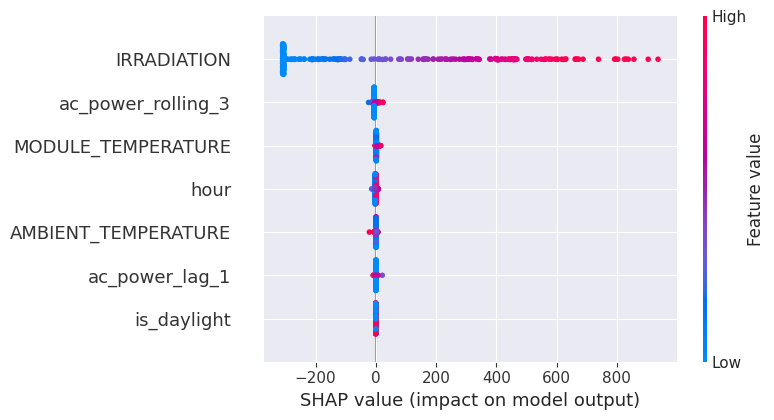

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)
X_sample = X_test.sample(min(300, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('/content/shap_summary_solar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import joblib

joblib.dump(rf, '/content/solar_model.pkl')
joblib.dump(feature_cols, '/content/solar_model_columns.pkl')

print("Model saved.")

from google.colab import files
files.download('/content/solar_model.pkl')
files.download('/content/solar_model_columns.pkl')


Model saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>